In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# ------------------ DATA GENERATION ------------------
np.random.seed(42)
n = 100

df = pl.DataFrame({
    "Experience": np.random.randint(1, 15, n),
    "Salary": np.random.randint(30000, 150000, n),
    "Performance": np.random.uniform(1, 10, n),
    "Dept": np.random.choice(["IT", "Sales", "HR", "Marketing"], n)
})

# ------------------ CLEANING ------------------
avg_salary = df.select(pl.col("Salary").mean()).to_numpy()[0][0]

df = df.with_columns(
    pl.when(pl.col("Salary") < 40000)
    .then(None)
    .otherwise(pl.col("Salary"))
    .alias("Salary")
)

df = df.with_columns(
    pl.col("Salary").fill_null(avg_salary)
)

# ------------------ FEATURE ENGINEERING ------------------
df = df.with_columns([
    (pl.col("Salary") / (pl.col("Experience") + 1)).alias("Efficiency_Score"),
    pl.when(pl.col("Performance") > 8)
    .then(pl.lit("Top_Tier"))
    .otherwise(pl.lit("Standard"))
    .alias("Tier")
])

# ------------------ AGGREGATION ------------------
stats = df.group_by("Dept").agg([
    pl.col("Salary").mean().alias("Avg_Sal"),
    pl.col("Performance").mean().alias("Avg_Perf")
])

print("Department Stats:\n", stats)

# ------------------ CONVERT TO NUMPY ------------------
exp = df["Experience"].to_numpy()
sal = df["Salary"].to_numpy()
perf = df["Performance"].to_numpy()
dept = df["Dept"].to_list()


Department Stats:
 shape: (4, 3)
┌───────────┬───────────────┬──────────┐
│ Dept      ┆ Avg_Sal       ┆ Avg_Perf │
│ ---       ┆ ---           ┆ ---      │
│ str       ┆ f64           ┆ f64      │
╞═══════════╪═══════════════╪══════════╡
│ HR        ┆ 103245.981818 ┆ 5.35361  │
│ IT        ┆ 100956.842308 ┆ 5.928686 │
│ Sales     ┆ 95639.040909  ┆ 5.871724 │
│ Marketing ┆ 93612.296667  ┆ 4.815801 │
└───────────┴───────────────┴──────────┘


C:\Users\HP\AppData\Local\Temp\ipykernel_8704\3819614187.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats.to_pandas(), x='Dept', y='Avg_Sal', palette='viridis')


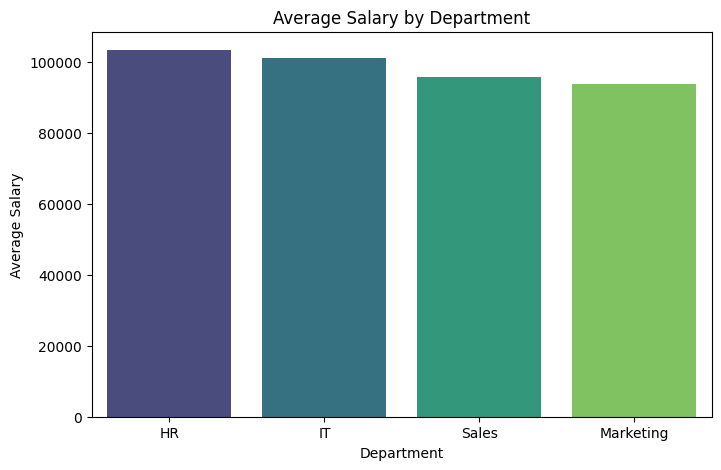

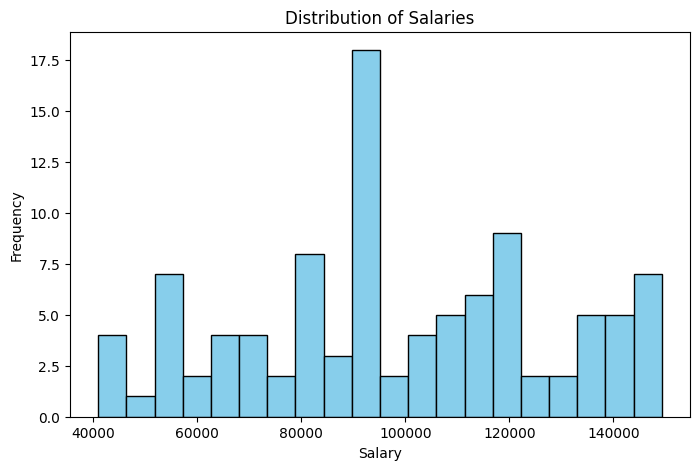

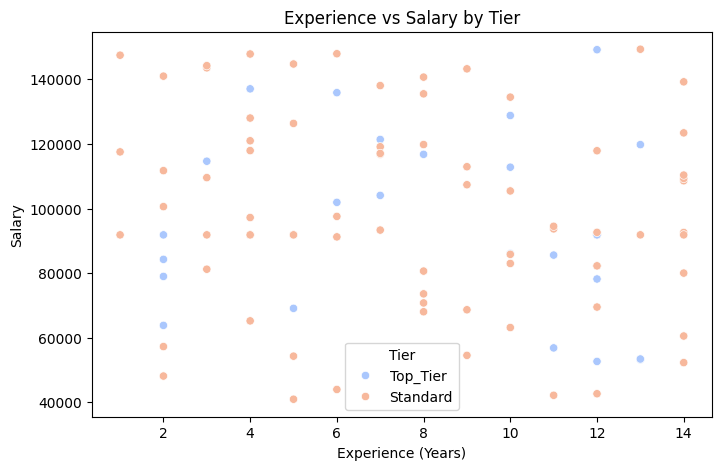

C:\Users\HP\AppData\Local\Temp\ipykernel_8704\3819614187.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.to_pandas(), x='Dept', y='Performance', palette='Set2')


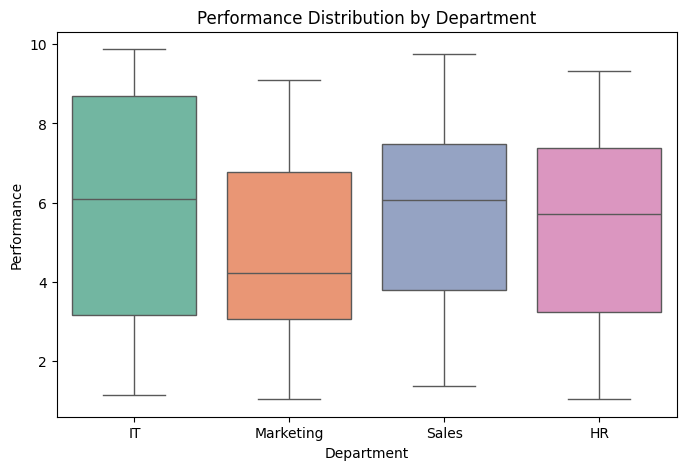

In [3]:
# ------------------ VISUALIZATION ------------------
import seaborn as sns

# Bar plot for average salary by department
plt.figure(figsize=(8, 5))
sns.barplot(data=stats.to_pandas(), x='Dept', y='Avg_Sal', palette='viridis')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.show()

# Histogram of salaries
plt.figure(figsize=(8, 5))
plt.hist(sal, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Salaries')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

# Scatter plot: Experience vs Salary, colored by Tier
plt.figure(figsize=(8, 5))
sns.scatterplot(x=exp, y=sal, hue=df['Tier'].to_list(), palette='coolwarm')
plt.title('Experience vs Salary by Tier')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary')
plt.legend(title='Tier')
plt.show()

# Box plot for performance by department
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.to_pandas(), x='Dept', y='Performance', palette='Set2')
plt.title('Performance Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Performance')
plt.show()